In [1]:
import numpy as np
import pandas as pd 

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.sample(5)

,Unnamed: 0,cgpa,iq,placement
12,12,5.4,139.0,0
79,79,6.5,90.0,1
36,36,5.7,140.0,0
64,64,7.0,64.0,1
39,39,4.6,146.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [7]:
# Steps 
# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [8]:
df = df.iloc[:,1:]
df.sample(5)

,cgpa,iq,placement
84,5.7,169.0,0
72,7.3,116.0,1
70,6.3,127.0,1
58,8.0,79.0,1
20,6.6,120.0,1


In [9]:
import matplotlib.pyplot as plt

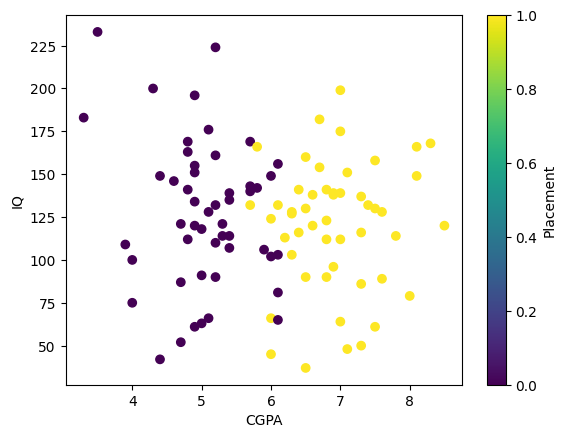

In [11]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'], cmap='viridis')
plt.colorbar(label='Placement')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.show()


In [12]:
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,2],test_size=0.2,random_state=42)

In [23]:
X_train.head()

,cgpa,iq
55,7.8,114.0
88,4.4,149.0
26,7.0,199.0
42,7.6,89.0
69,8.5,120.0


In [24]:
y_train.head()

55    1
88    0
26    1
42    1
69    1
Name: placement, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [28]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 1.64027754, -0.29911792],
       [-1.44090679,  0.59472432],
       [ 0.91529299,  1.87164179],
       [ 1.4590314 , -0.93757666],
       [ 2.27463902, -0.14588782],
       [-0.80654531,  1.28425975],
       [-0.98779145,  0.21164907],
       [-1.44090679, -2.13787909],
       [-0.80654531, -1.5249587 ],
       [ 1.1871622 , -0.24804122],
       [ 0.82466992,  0.31380247],
       [-0.71592224,  0.90118451],
       [-0.17218383,  1.02887626],
       [-0.71592224, -0.91203831],
       [ 0.73404686, -0.35019462],
       [ 1.00591606, -1.98464899],
       [ 0.82466992, -0.75880821],
       [ 1.91214675,  1.02887626],
       [ 0.73404686, -0.91203831],
       [-0.71592224,  2.51010053],
       [-0.5346761 ,  0.23718742],
       [-1.07841452,  0.95226121],
       [-0.89716838, -1.60157375],
       [-1.53152986,  1.89718014],
       [ 0.00906231, -0.04373442],
       [-0.71592224,  0.16057237],
       [-0.5346761 , -0.47788637],
       [-0.89716838, -0.88649996],
       [ 0.00906231,

In [29]:
X_test = scaler.transform(X_test)

C:\Users\Mohammad Tofik\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [30]:
X_test

array([[  7.5, 130. ],
       [  8.3, 168. ],
       [  6.3, 127. ],
       [  6. ,  66. ],
       [  7.5,  61. ],
       [  4.6, 146. ],
       [  4.9, 120. ],
       [  4.9, 196. ],
       [  6. ,  45. ],
       [  6.8, 123. ],
       [  4. , 100. ],
       [  7.6, 128. ],
       [  4.9,  61. ],
       [  6. , 149. ],
       [  7.3,  86. ],
       [  5.8, 142. ],
       [  4.9, 155. ],
       [  7.3,  50. ],
       [  5.4, 139. ],
       [  3.9, 109. ]])

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
lr = LogisticRegression()

In [43]:
lr.fit(X_train,y_train)

LogisticRegression()

In [44]:
y_pred = lr.predict(X_test)

In [45]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [46]:
from sklearn.metrics import accuracy_score

In [47]:
ac =accuracy_score(y_test,y_pred)

In [48]:
ac

0.5

In [51]:
import pickle

In [52]:
pickle.dump(lr,open('practice_model.pkl','wb'))